In [1]:
import sys
import os
import jax
import jax.numpy as np
import amigo
import ehtplot
import scienceplots
import cmasher
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from dLux import utils as dlu
from zodiax.optimisation import sgd, adam
import dorito

# Basic jax import
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)

# # Check if running on remote, and set directory to where notebook is run
# if jax.devices()[0].platform == "gpu":
#     os.chdir("code/amigo_project/notebooks/calibration")

# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ['..', "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)
        
# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

plt.style.use(["science", "bright", "no-latex"])

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)


def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)

In [2]:
def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)


# Add extra bad pixels
def add_badpix(file):
    file["BADPIX"].data[:1, :] = 1
    file["BADPIX"].data[-1:, :] = 1
    file["BADPIX"].data[:, :1] = 1
    file["BADPIX"].data[:, -1:] = 1
    file["BADPIX"].data[41:43, 1] = 1
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[43, 0] = 1
    file["BADPIX"].data[44, 70] = 1
    file["BADPIX"].data[4, 45] = 1
    file["BADPIX"].data[58, 14] = 1
    file["BADPIX"].data[61, 54] = 1
    file["BADPIX"].data[51, 27] = 1
    return file

In [3]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
    data_path = "/media/morgana1/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/media/morgana1/snert/max/data/JWST/WR137/uncal/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
    data_path = "/Volumes/morgana1/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/Volumes/morgana1/snert/max/data/JWST/WR137/uncal/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
init_state_cache = os.path.join(cache, "init_states/WR137/")
output_path = os.path.join(cache, "outputs/WR137/")
K_path = os.path.join(cache, "K/")
fig_path = os.path.join(cache, "figs/")

state = np.load(os.path.join(model_cache, "cal_model.npy"), allow_pickle=True).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
files = [add_badpix(file) for file in files]

# Log Amplitudes and phases

In [5]:
from amigo.misc import tqdm
import zodiax as zdx
from amigo.vis_models import model_vis_psf
from amigo.stats import batched_jacobian, decompose
import dLux.utils as dlu

do_calcs = False

optics = amigo.optical_models.AMIOptics()
if do_calcs:
    n_terms = 250
    eig_mats = {"amplitude": {}, "phase": {}}

else:
    print("is this taking ages")
    eig_mats = zdx.experimental.deserialise(K_path + "eigmats.zdx")
    print("this is taking ages")
    amp_vals = np.load(K_path + "ampvals.npy")
    amp_vecs = np.load(K_path + "ampvecs.npy")
    phase_vals = np.load(K_path + "phasevals.npy")
    phase_vecs = np.load(K_path + "phasevecs.npy")
    H_amp = np.load(K_path + "H_amp.npy")
    H_phase = np.load(K_path + "H_phase.npy")

# for filt in ["F380M", "F430M", "F480M"]:

#     if do_calcs:
#         n_knots = 51
#         n_pts = (n_knots**2) - 1  # dont control the DC term
#         vis_vec = np.zeros(n_pts)
#         abb = state["aberrations"]
#         defoc = state["defocus"][filt]

#         #
#         output_fn = lambda x: dlu.downsample(x, 3, mean=False).flatten()
#         vis_fn = lambda vis_vec: output_fn(
#             model_vis_psf(optics, vis_vec, filt, abb, defoc, n_knots)
#         )
#         psf = vis_fn(vis_vec)

#         print("chat we made it")

#         J = batched_jacobian(vis_vec, lambda X: vis_fn(X), n_batch=40)
#         J_amp, J_phase = np.split(J, 2, axis=0)

#         # Amplitudes
#         print("doin amps")
#         H_amp, amp_vals, amp_vecs = decompose(J_amp, psf)
#         eig_mats["amplitude"][filt] = amp_vecs

#         # Phases
#         print("doin phases")
#         H_phase, phase_vals, phase_vecs = decompose(J_phase, psf)
#         eig_mats["phase"][filt] = phase_vecs

#     plt.figure(figsize=(10, 4))
#     plt.suptitle(f"{filt} Hessian")

#     plt.subplot(1, 2, 1)
#     plt.title("Amplitude")
#     plt.imshow(np.abs(H_amp) ** 0.1, cmap="inferno")
#     plt.colorbar()

#     plt.subplot(1, 2, 2)
#     plt.title("Phase")
#     plt.imshow(np.abs(H_phase) ** 0.1, cmap="inferno")
#     plt.colorbar()

#     plt.tight_layout()
#     plt.show()

#     plt.figure(figsize=(10, 4))
#     plt.title(f"{filt} Eigenvalues")
#     plt.plot(amp_vals, label="Amplitude")
#     plt.plot(phase_vals, label="Phase")
#     plt.yscale("log")
#     plt.tight_layout()
#     plt.show()

is this taking ages
this is taking ages


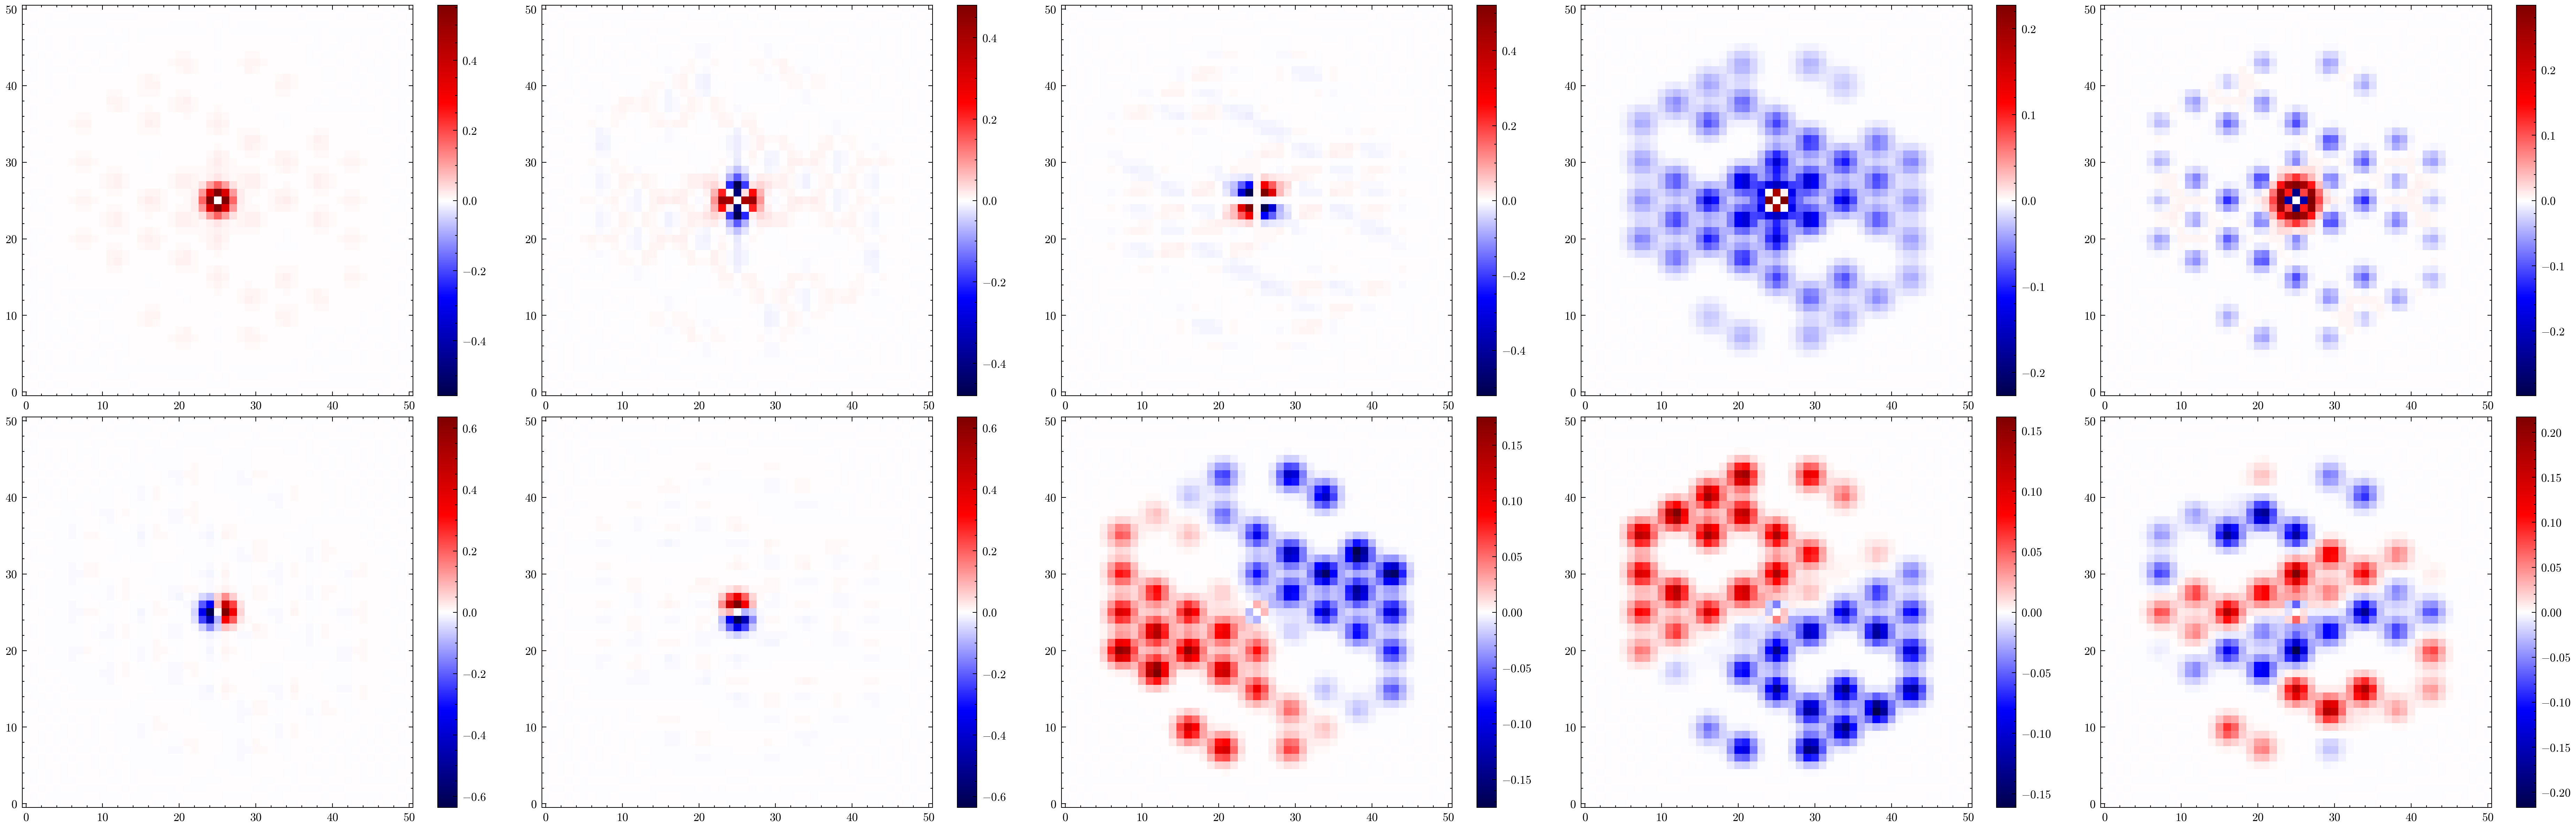

In [6]:
from amigo.vis_models import vis_to_im

plt.figure(figsize=(25, 8))
for i in range(5):
    log_amp, phase = vis_to_im(amp_vecs[i], phase_vecs[i], (51, 51))

    v = np.nanmax(np.abs(log_amp))
    plt.subplot(2, 5, i + 1)
    plt.imshow(log_amp, seismic, vmin=-v, vmax=v)
    plt.colorbar()

    v = np.nanmax(np.abs(phase))
    plt.subplot(2, 5, i + 6)
    plt.imshow(phase, seismic, vmin=-v, vmax=v)
    plt.colorbar()

plt.tight_layout()
plt.show()

In [7]:
# n_basis = 150

# plt.figure(figsize=(25, 8))
# for i in range(5):
#     latent_amp, latent_phase = jr.normal(jr.key(i), (2, n_basis))
#     log_amp = np.dot(latent_amp, amp_vecs[:n_basis])
#     phase = np.dot(latent_phase, phase_vecs[:n_basis])
#     log_amp, phase = vis_to_im(log_amp, phase, (51, 51))

#     v = np.nanmax(np.abs(log_amp))
#     plt.subplot(2, 5, i + 1)
#     plt.imshow(log_amp, seismic, vmin=-v, vmax=v)
#     plt.colorbar()

#     v = np.nanmax(np.abs(phase))
#     plt.subplot(2, 5, i + 6)
#     plt.imshow(phase, seismic, vmin=-v, vmax=v)
#     plt.colorbar()

# plt.tight_layout()
# plt.show()

In [97]:
from amigo.vis_models import LogVisModel

otf_coords = dlu.pixel_coords(51, 2 * optics.diameter)
vis_model = LogVisModel(
    eig_mats["amplitude"],
    eig_mats["phase"],
    otf_coords,
    n_terms=480,
)

In [98]:
from amigo.ramp_models import DFRNN, RNNRamp
from amigo.detector_models import PixelSensitivity
from jax import random as jr


ramp_model = RNNRamp(DFRNN(jr.key(0)), gain_model=PixelSensitivity(), norm=2**14)

In [118]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import SUB80Detector
from amigo.read_models import ReadModel
from amigo.model_fits import SplineVisFit


# Get the model
exposures = [SplineVisFit(file) for file in files[-1:]]
model = AmigoModel(
    exposures=exposures,
    optics=optics,
    detector=SUB80Detector(ramp_model=ramp_model),
    read=ReadModel(),
    vis_model=vis_model,
)

# state = np.load("../../GPU_files/results/cal_model.npy", allow_pickle=True).item()
from jax import tree as jtu

x = model
for key, value in state.items():
    if key in ["aberrations"]:
        print(key, value)
        model = model.set("aberrations", jtu.map(lambda x: value, model.aberrations))
        continue
    model = model.set(key, value)

y = model

aberrations [[   0.           -2.91490501  -31.47756919  -23.03275208   30.8886053
    16.84188043   -2.68376884   -5.87690776   10.66706189    2.43681997]
 [-133.3683084   -40.79704387  -19.3547213   -28.4130696     4.33656301
    -6.58841075   -6.75178334   16.72001996  -42.11102185  -15.74680959]
 [-117.71598753   34.7421253    -9.0103794    18.34381586    6.09933542
     9.3533208   -13.09554588    2.30943658  -26.17034767   -8.40312801]
 [ -49.37668241  -26.59070847  -29.33842058   21.21241813   36.78671913
    15.1081097    -9.39901265   15.31750083    1.16256581   13.09894686]
 [ 100.16835326  -18.23241307  -20.57246899   -6.45234914   39.52776605
    -2.39606139   -8.22324321   19.99688124   -2.11182743   -9.05544328]
 [ -88.80965057   13.74784726  -12.5993374   -18.63977966   36.79980879
    11.84187446  -27.30109718   16.18454753   10.77211791  -23.21101408]
 [  87.14925477  -12.668276    -50.72917386   12.48172642   57.3326044
     1.88275863  -18.80718151   13.6172253    -8

01349_F480M


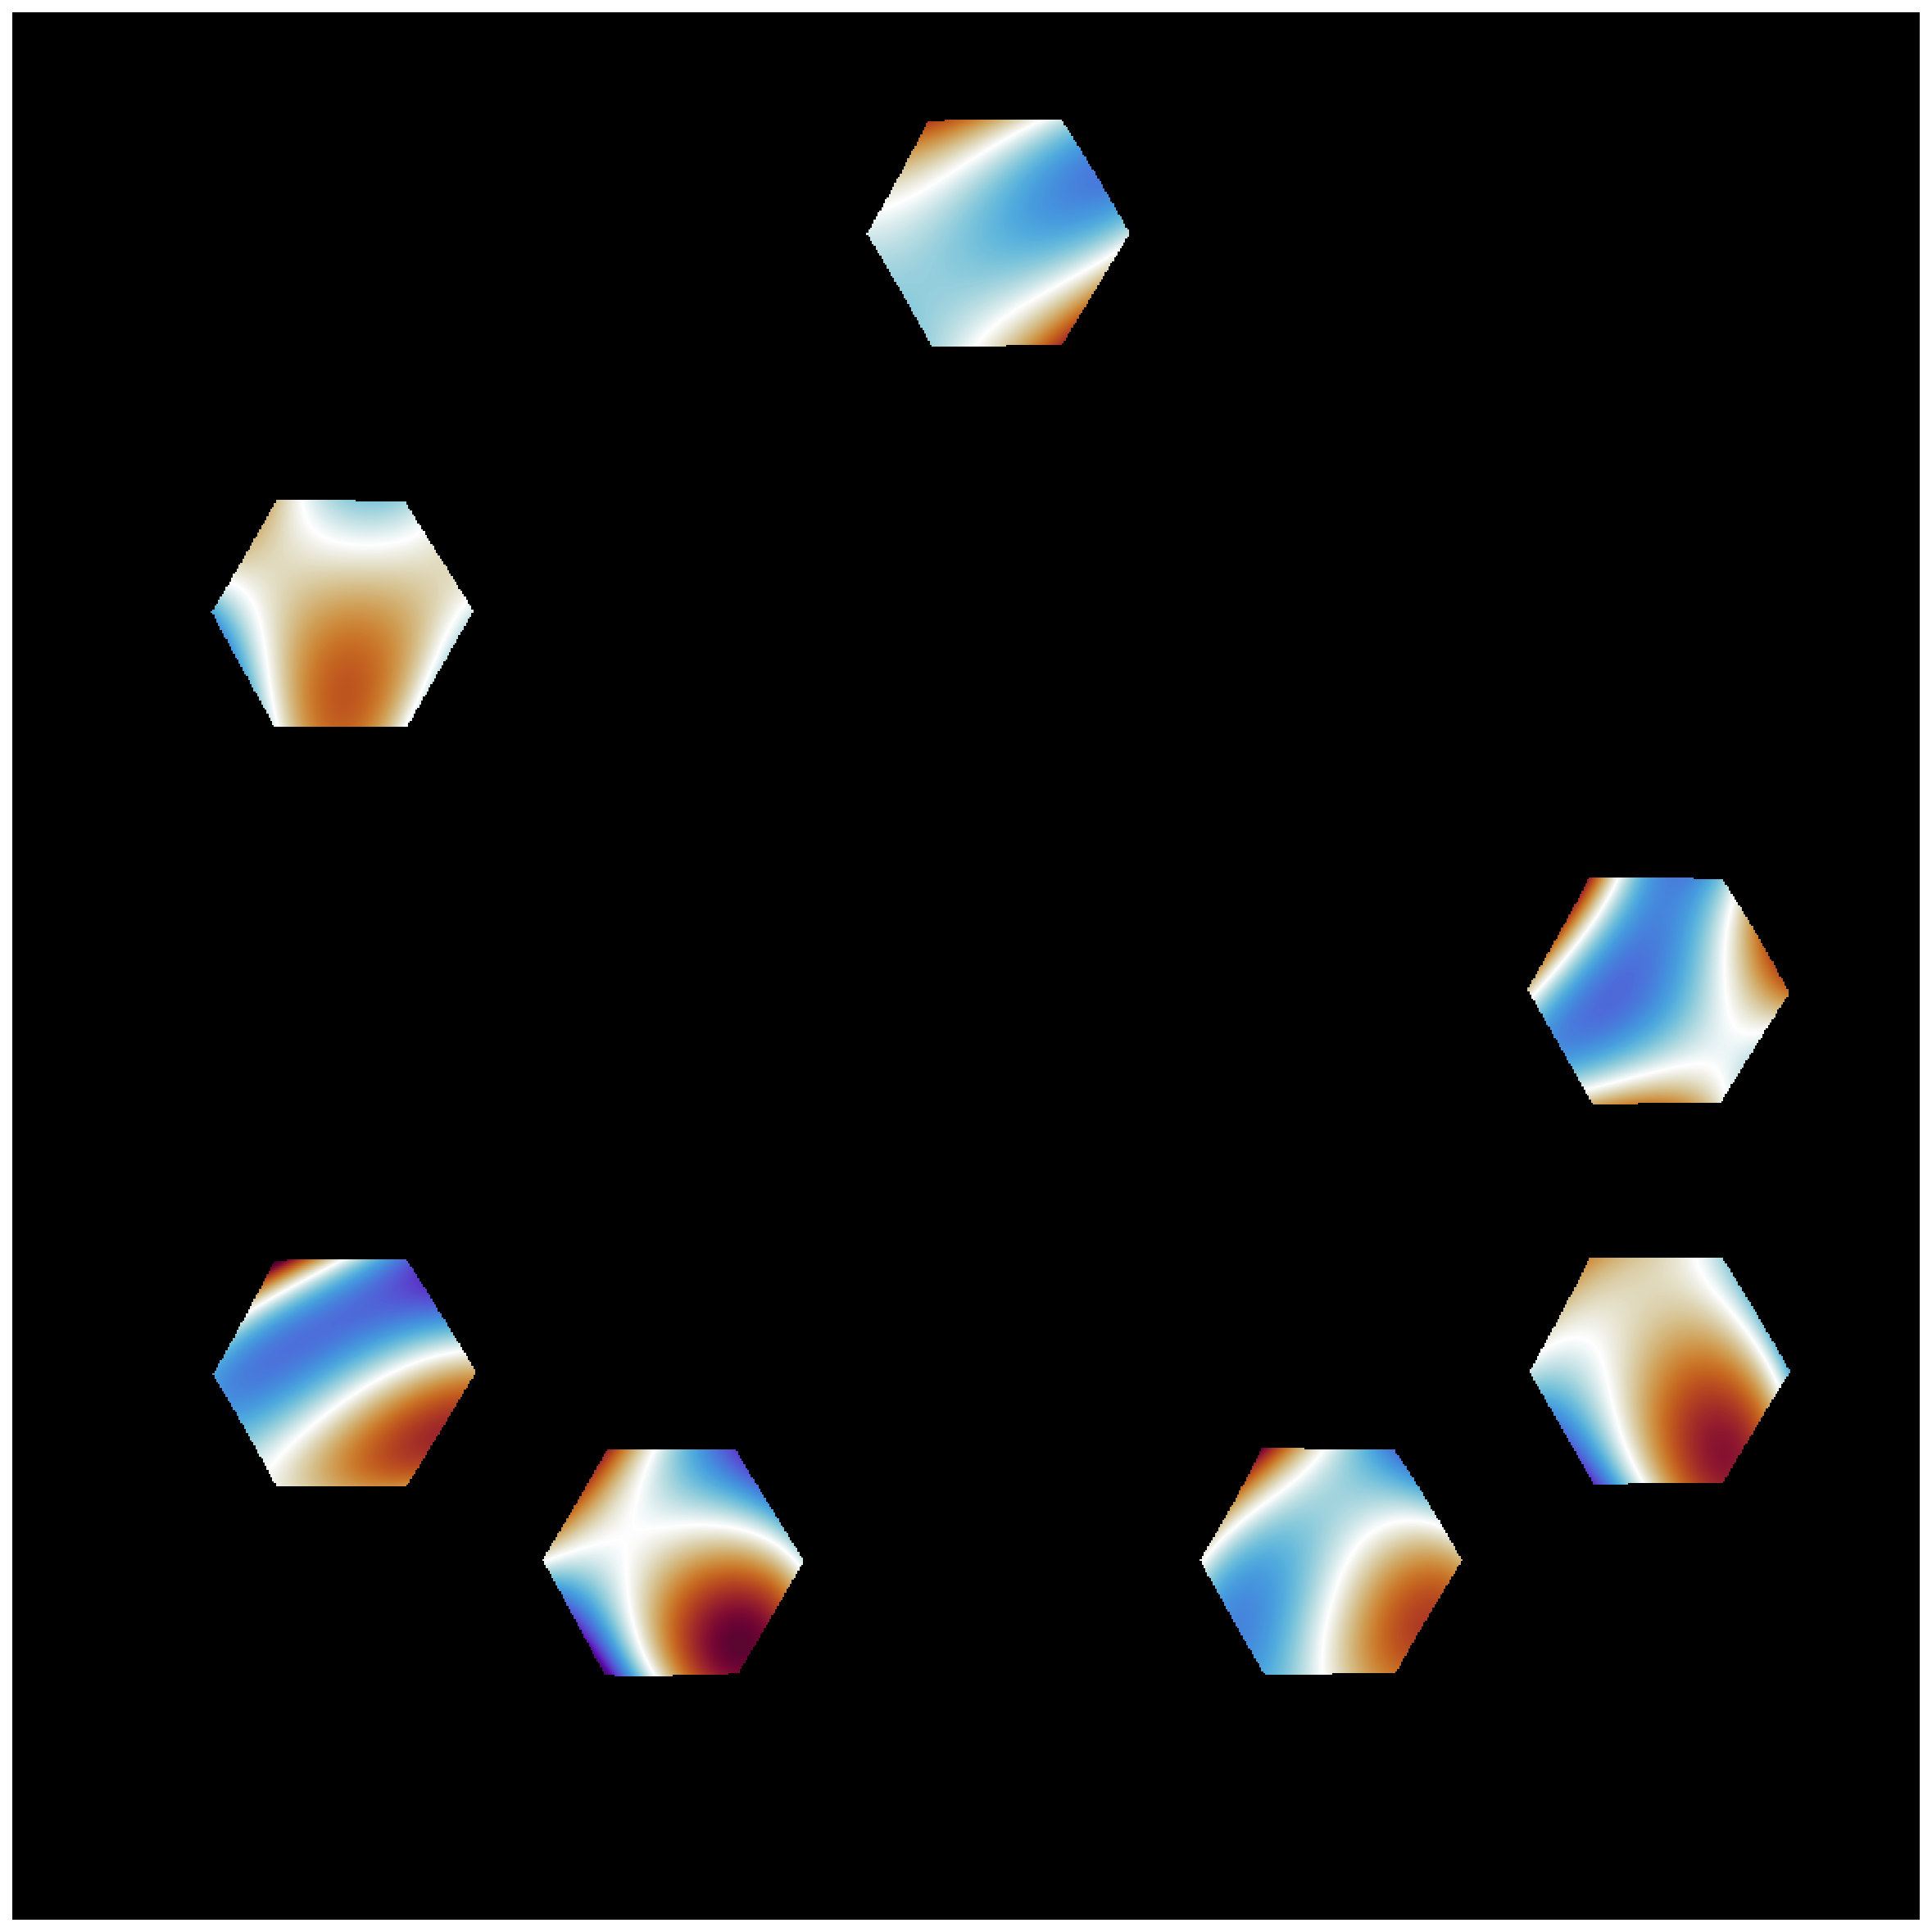

In [119]:
cmap = mpl.colormaps["cmr.fusion"]
cmap.set_bad("k", 1.0)

cal_aberrations = {
    key: val for key, val in model.aberrations.items()
}  # if "04481" in key}

optics = model.optics
pupil_mask = model.optics.pupil_mask

plt.figure(figsize=(8, 8))
# plt.suptitle("Primary Mirror Aberrations")
for i, key in enumerate(cal_aberrations):
    filt = key.split("_")[-1]
    print(key)

    coeffs = model.aberrations[key]
    full_abb = pupil_mask.set("abb_coeffs", coeffs).calc_aberrations()
    flat_abb = pupil_mask.set("abb_coeffs", coeffs.at[:, :3].set(0)).calc_aberrations()

    mask = pupil_mask.transmission

    full_abb = np.where(mask < 1.0, np.nan, 1e9 * full_abb)
    flat_abb = np.where(mask < 1.0, np.nan, 1e9 * flat_abb)

    full_abb -= np.nanmean(full_abb)
    flat_abb -= np.nanmean(flat_abb)

    rms = lambda x: np.sqrt(np.nanmean(np.square(x)))

    v = np.nanmax(np.abs(flat_abb))
    # plt.subplot(1, 3, i + 1)
    # plt.title(f"{filt} - RMS: {rms(flat_abb):.2f} nm")
    plt.imshow(flat_abb, cmap, vmin=-v, vmax=v)
    plt.axis("off")
    # plt.colorbar(label="OPD (nm)")

plt.tight_layout()
plt.savefig(fig_path + "wavefront.png", dpi=300, bbox_inches="tight")
plt.show()

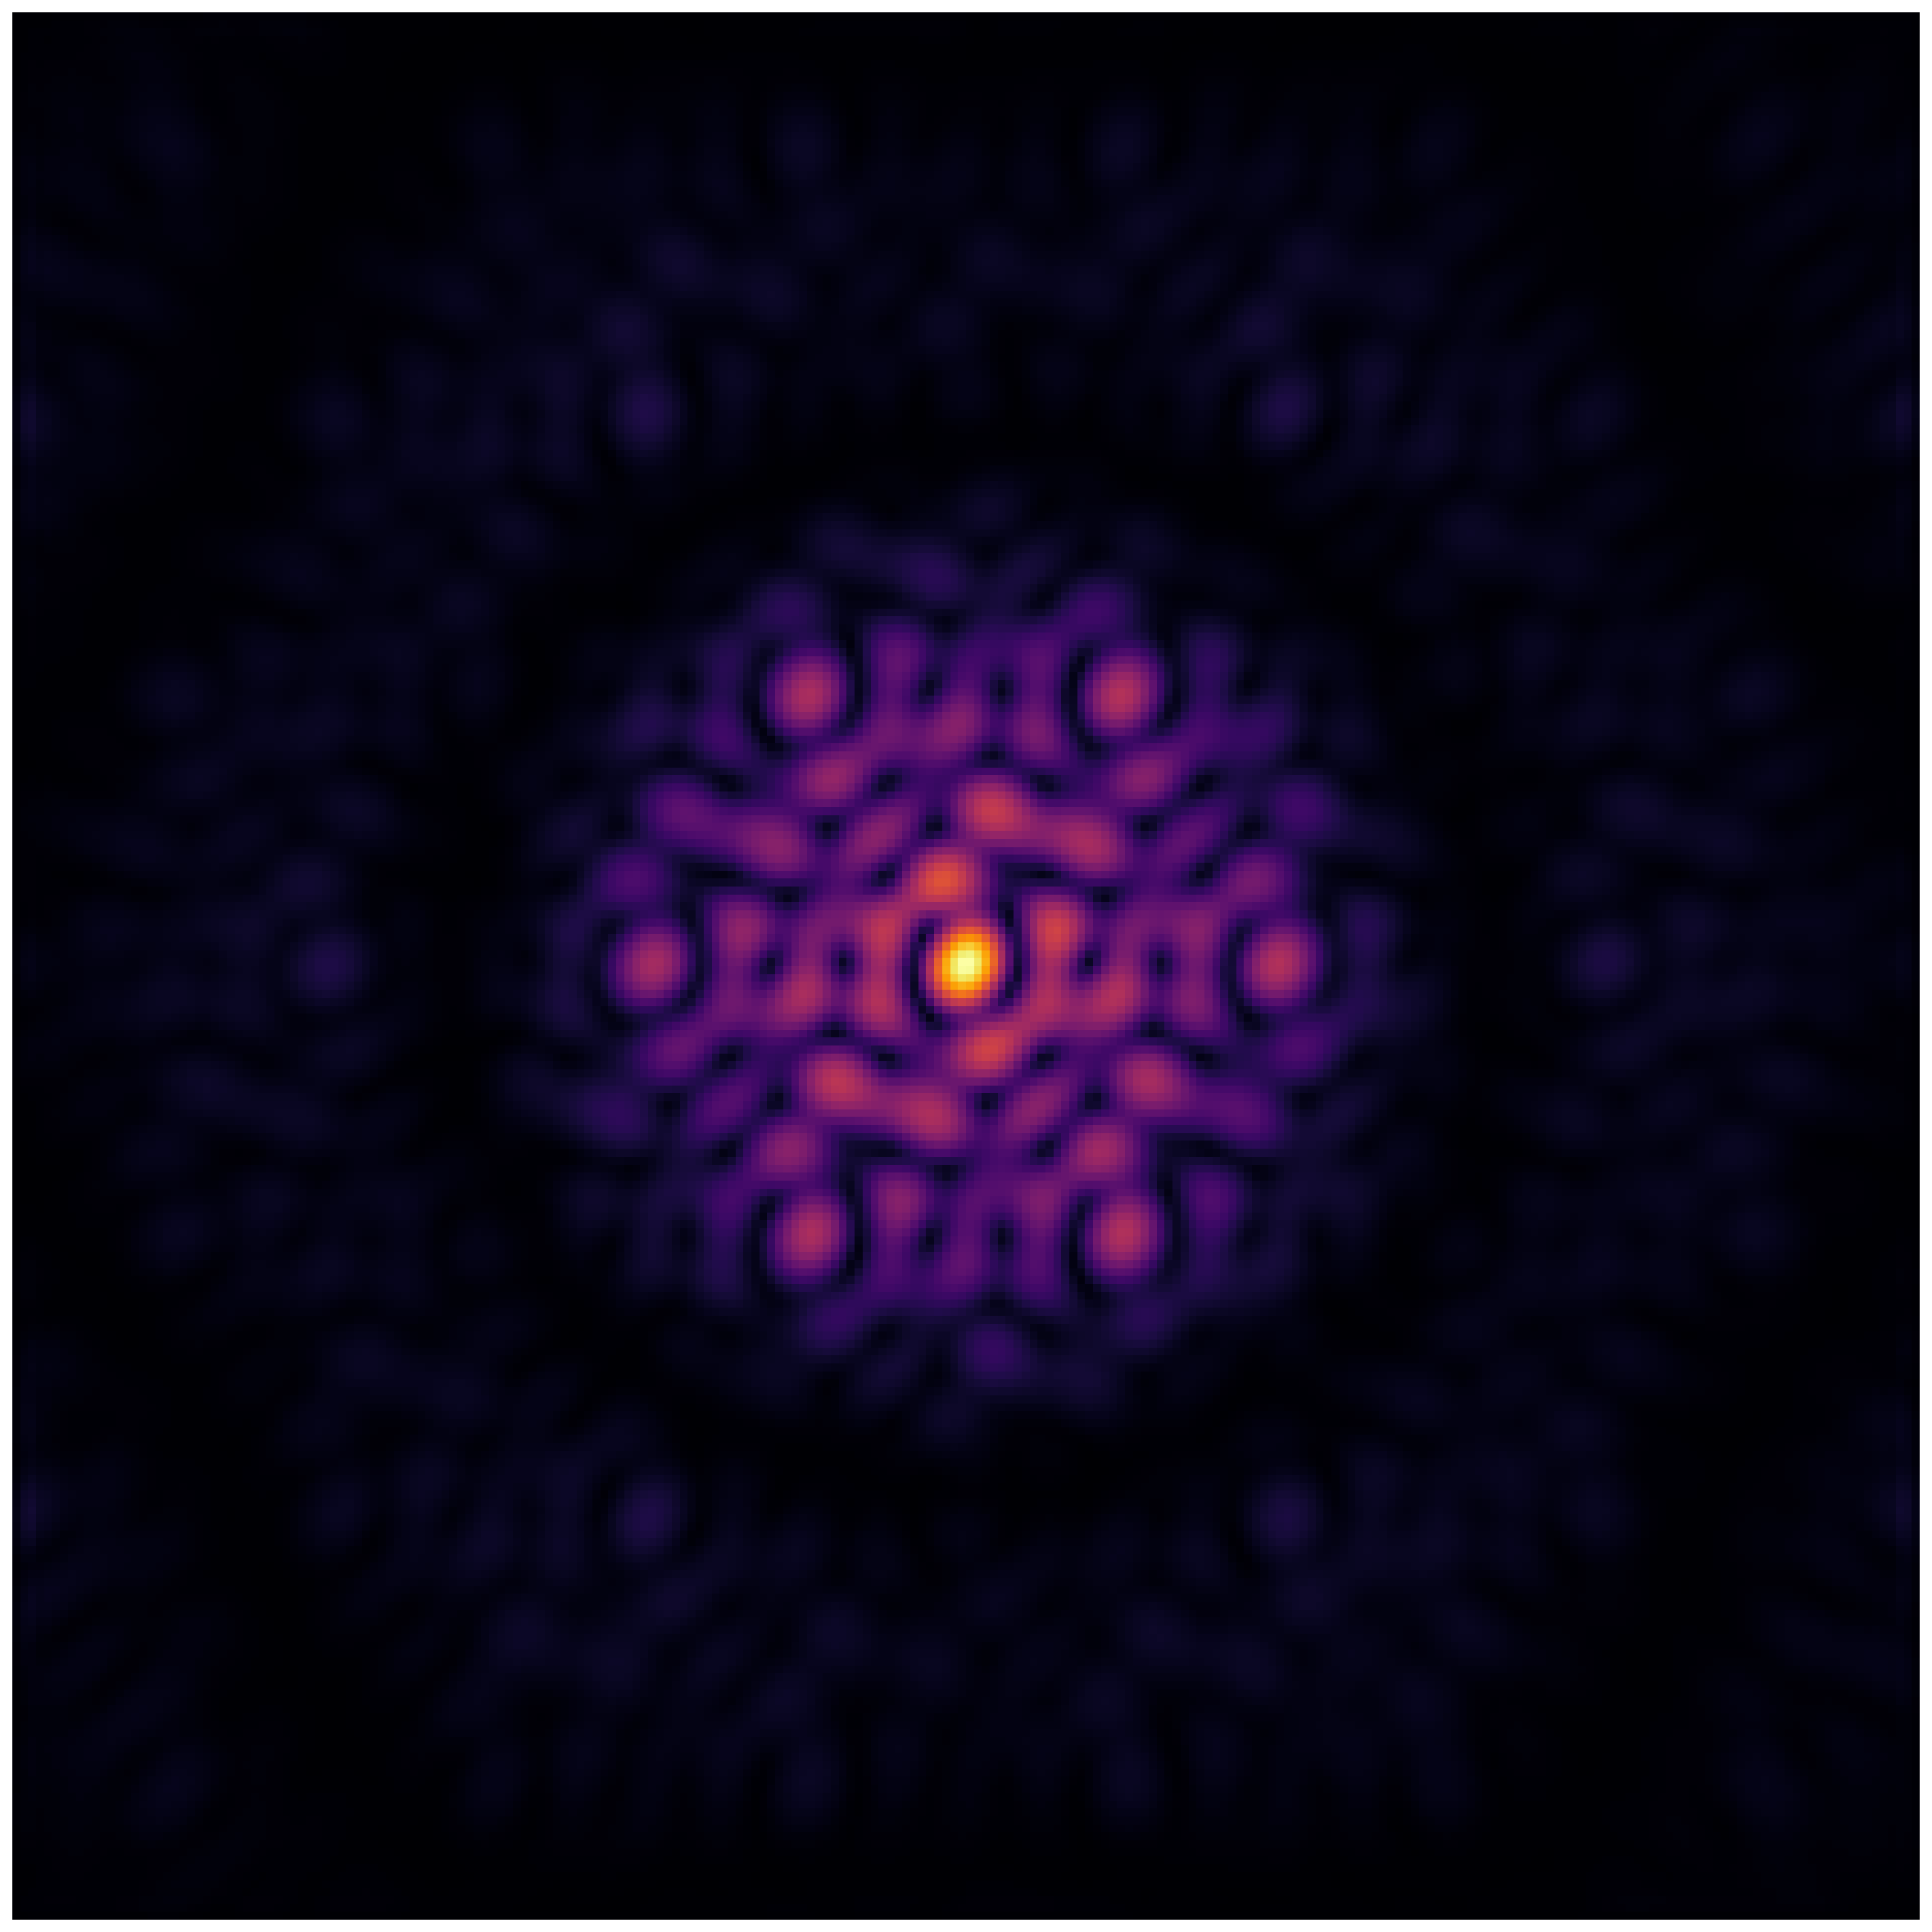

In [120]:
exp = exposures[0]

model = model.set("positions", jtu.map(lambda x: 0 * x, model.positions))
psf = exp.model_psf(model)

plt.figure(figsize=(8, 8))
plt.imshow(psf.data, norm=mpl.colors.PowerNorm(0.5), cmap="inferno")
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "psf.png", dpi=300, bbox_inches="tight")
plt.show()

In [129]:
from amigo.vis_models import wf_fft_coords, vis_to_im
from amigo.misc import interp
from jax import vmap

model = model.set("positions", jtu.map(lambda x: 0 * x, model.positions))
wfs = exp.model_wfs(model)

log_amps_ = np.zeros(model.vis_model.n_terms).at[:10].set(0.1)
phases_ = np.zeros(model.vis_model.n_terms).at[:10].set(0.1)

log_amps = np.dot(log_amps_, vis_model.V_amp["F430M"])
phases = np.dot(phases_, vis_model.V_phase["F430M"])
log_amps, phase = vis_to_im(log_amps, phases, otf_coords.shape[1:])

print(log_amps.shape, phases.shape)
print(otf_coords.shape)

# Interpolate the visibility maps to uv coordinates
uv_coords = wf_fft_coords(wfs, pad=2)
interp_fn = lambda im, uv: interp(im, otf_coords, uv, method="linear", fill=0.0)
log_amps = vmap(lambda uv: interp_fn(log_amps, uv))(uv_coords)
phases = vmap(lambda uv: interp_fn(phase, uv))(uv_coords)

# Fourier Functions (use 2x pad)
n = uv_coords.shape[-1] // 4
crop_fn = lambda x: x[n:-n, n:-n]
pad_fn = lambda x: np.pad(x, n, mode="constant")
to_uv = vmap(lambda x: np.fft.fftshift(np.fft.fft2(pad_fn(x))))
from_uv = vmap(lambda x: crop_fn(np.fft.ifft2(np.fft.ifftshift(x))))

# Apply the visibility maps
splodges = to_uv(wfs.psf)
# return np.abs(from_uv(splodges)).sum(0)

splodges.shape

(51, 51) (1300,)
(2, 51, 51)


(9, 480, 480)

In [122]:
def model_vis(self, wfs, model):
    # NOTE: Returns a psf

    # Get the visibilities
    amps = model.amplitudes[self.get_key("amplitudes")]
    phases = model.phases[self.get_key("phases")]
    return model.vis_model.model_vis(wfs, amps, phases, self.filter)

In [123]:
exp.get_key("amplitudes")

'WR137AMIREFPSF_F480M'

In [127]:
model.get(exp.map_param("amplitudes")).shape

(480,)

In [151]:
# p = model.params
# p["amplitudes"]["WR137AMIREFPSF_F480M"] = log_amps
# params["phases"][exp.get_key("phases")] = phases

x = model.set(exp.map_param("amplitudes"), 5 * log_amps_)
x = x.set(exp.map_param("phases"), 2 * phases_)

# intfg = exp.model_vis(wfs, x)

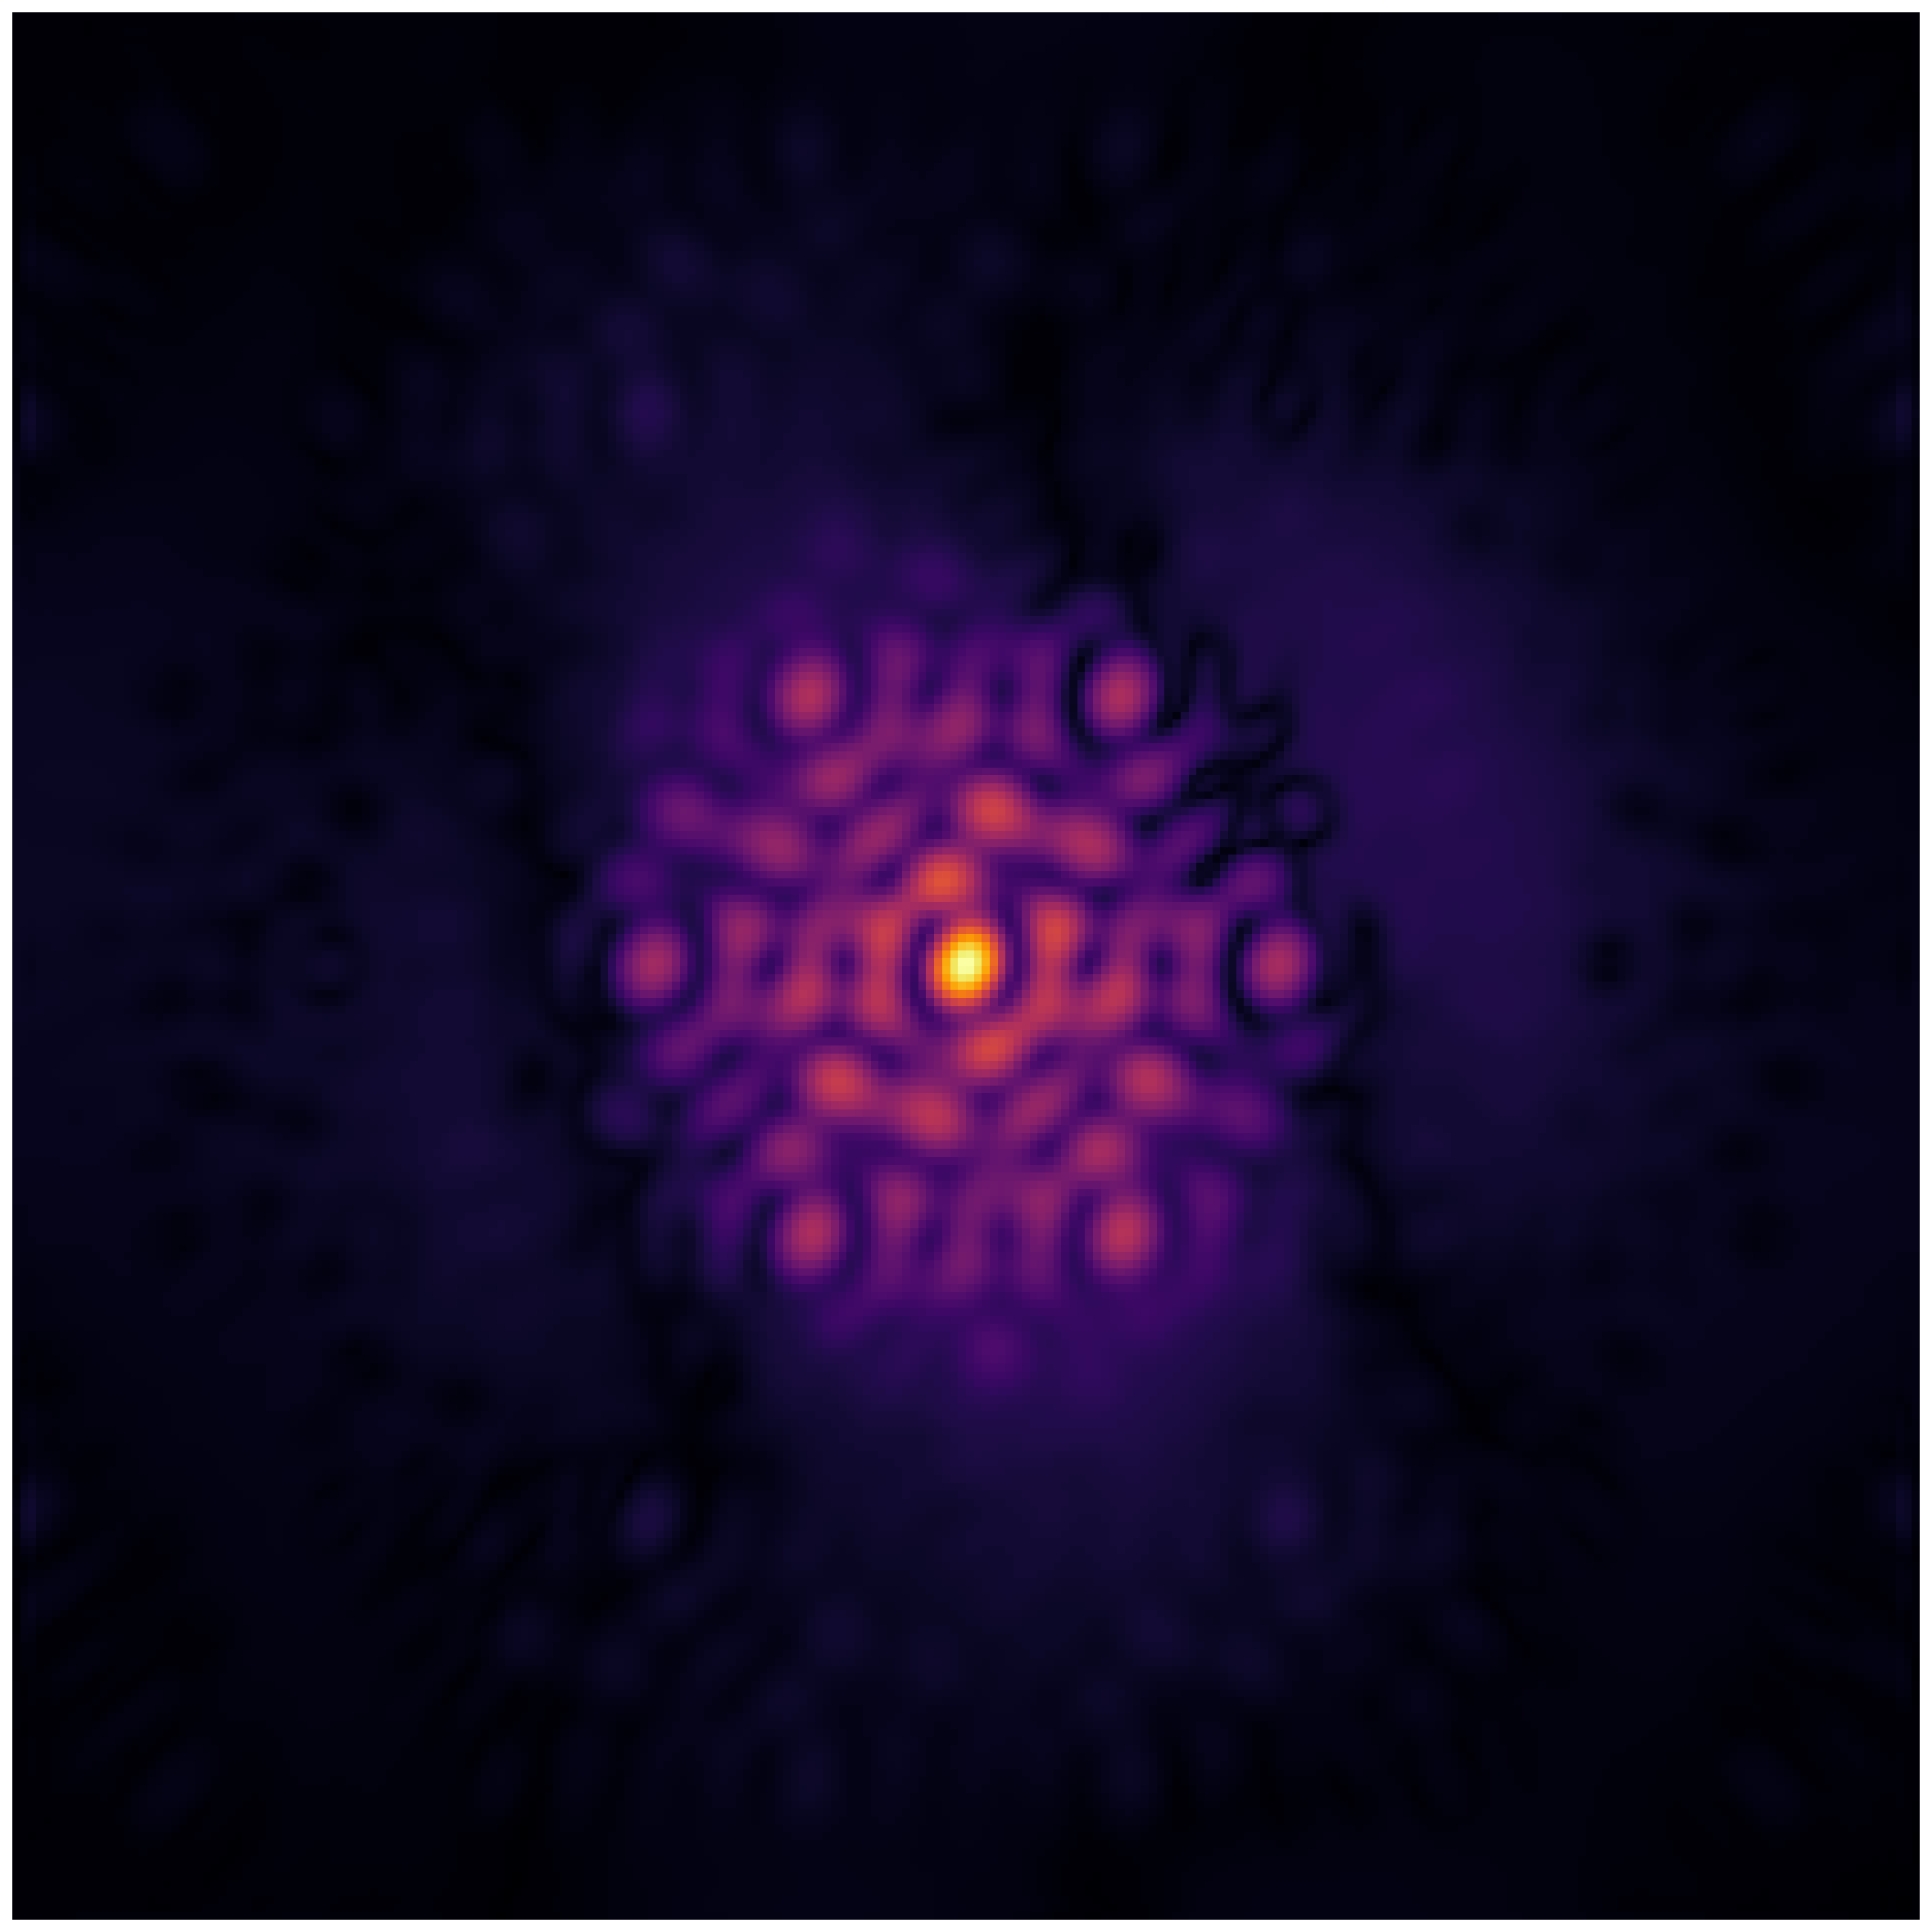

In [152]:
intfg = exp.model_vis(wfs, x).data

plt.figure(figsize=(8, 8))
plt.imshow(intfg, cmap="inferno", norm=mpl.colors.PowerNorm(0.5))
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "interferogram.png", dpi=300, bbox_inches="tight")
plt.show()

In [204]:
dlu.rad2deg(np.arctan(5 / 2))

68.19859051364818

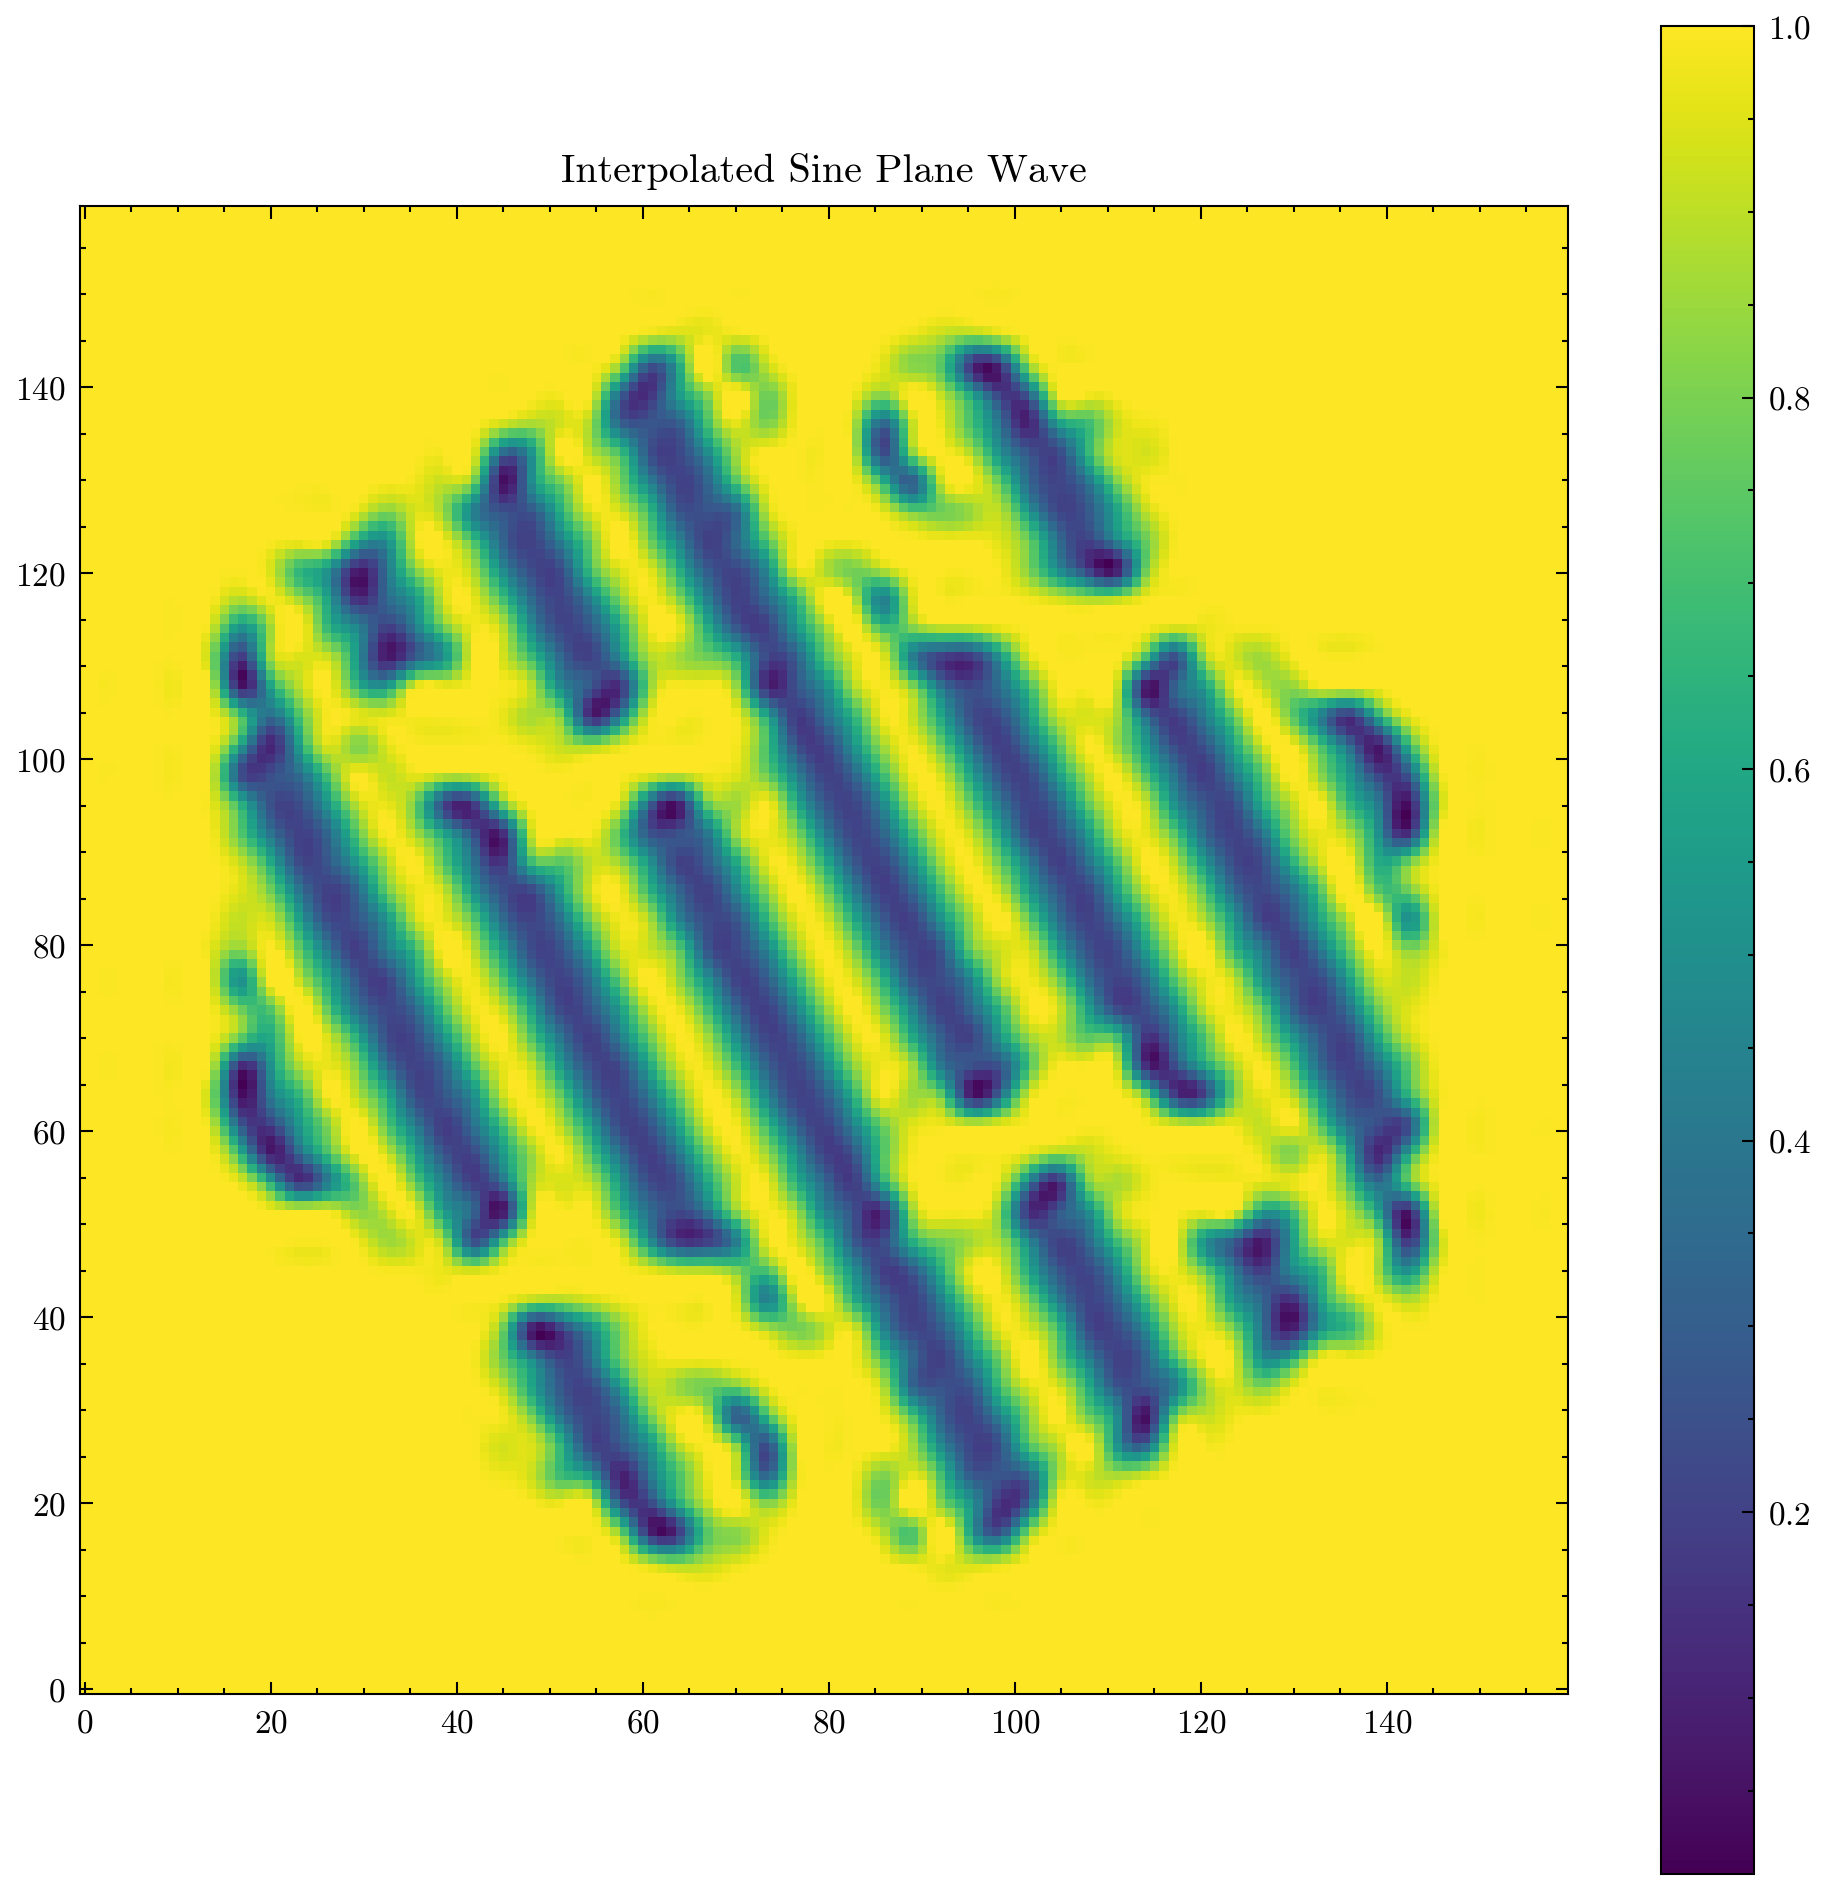

In [376]:
# Grid size
# nx, ny = 160, 160
nx, ny = 51, 51

# Spatial frequencies (cycles per unit length)
fy = 4  # frequency along x
fx = 2 * fy  # frequency along y

# Create grid
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = dlu.pixel_coords(nx, 1.0)
sample_coords = np.stack([X, Y])  # shape: (2, 480, 480)


# Sine plane wave
depth = 0.01
wave = depth * np.cos(2 * np.pi * (fx * X + fy * Y)) + (1 - depth)

# plt.imshow(wave)
# plt.colorbar()
# plt.title("Sine Plane Wave")
# plt.show()

wave = np.log(wave)
V_amp = model.vis_model.V_amp["F480M"]
p = wave.flatten()[: wave.size // 2]

coeffs = np.dot(p, np.linalg.pinv(V_amp))
vis = np.dot(coeffs, V_amp)


vis_map = vis_to_im(vis, np.zeros_like(vis), (nx, ny))[0]
vis_map = np.exp(vis_map)


# Sample coordinates (grid of output image)
X2, Y2 = dlu.pixel_coords(160, 1.0)
knot_coords = np.stack([X2, Y2])  # shape: (2, 480, 480)

# Interpolate
wave = amigo.misc.interp(vis_map, sample_coords, knot_coords, method="cubic2", fill=1.0)
wave = np.clip(wave, None, 1.0)

n = 40
wave -= 1 - depth
wave *= n
wave += 1 - n * depth

plt.figure(figsize=(8, 8))
plt.imshow(wave, cmap="viridis")
plt.title("Interpolated Sine Plane Wave")
plt.colorbar()
plt.show()

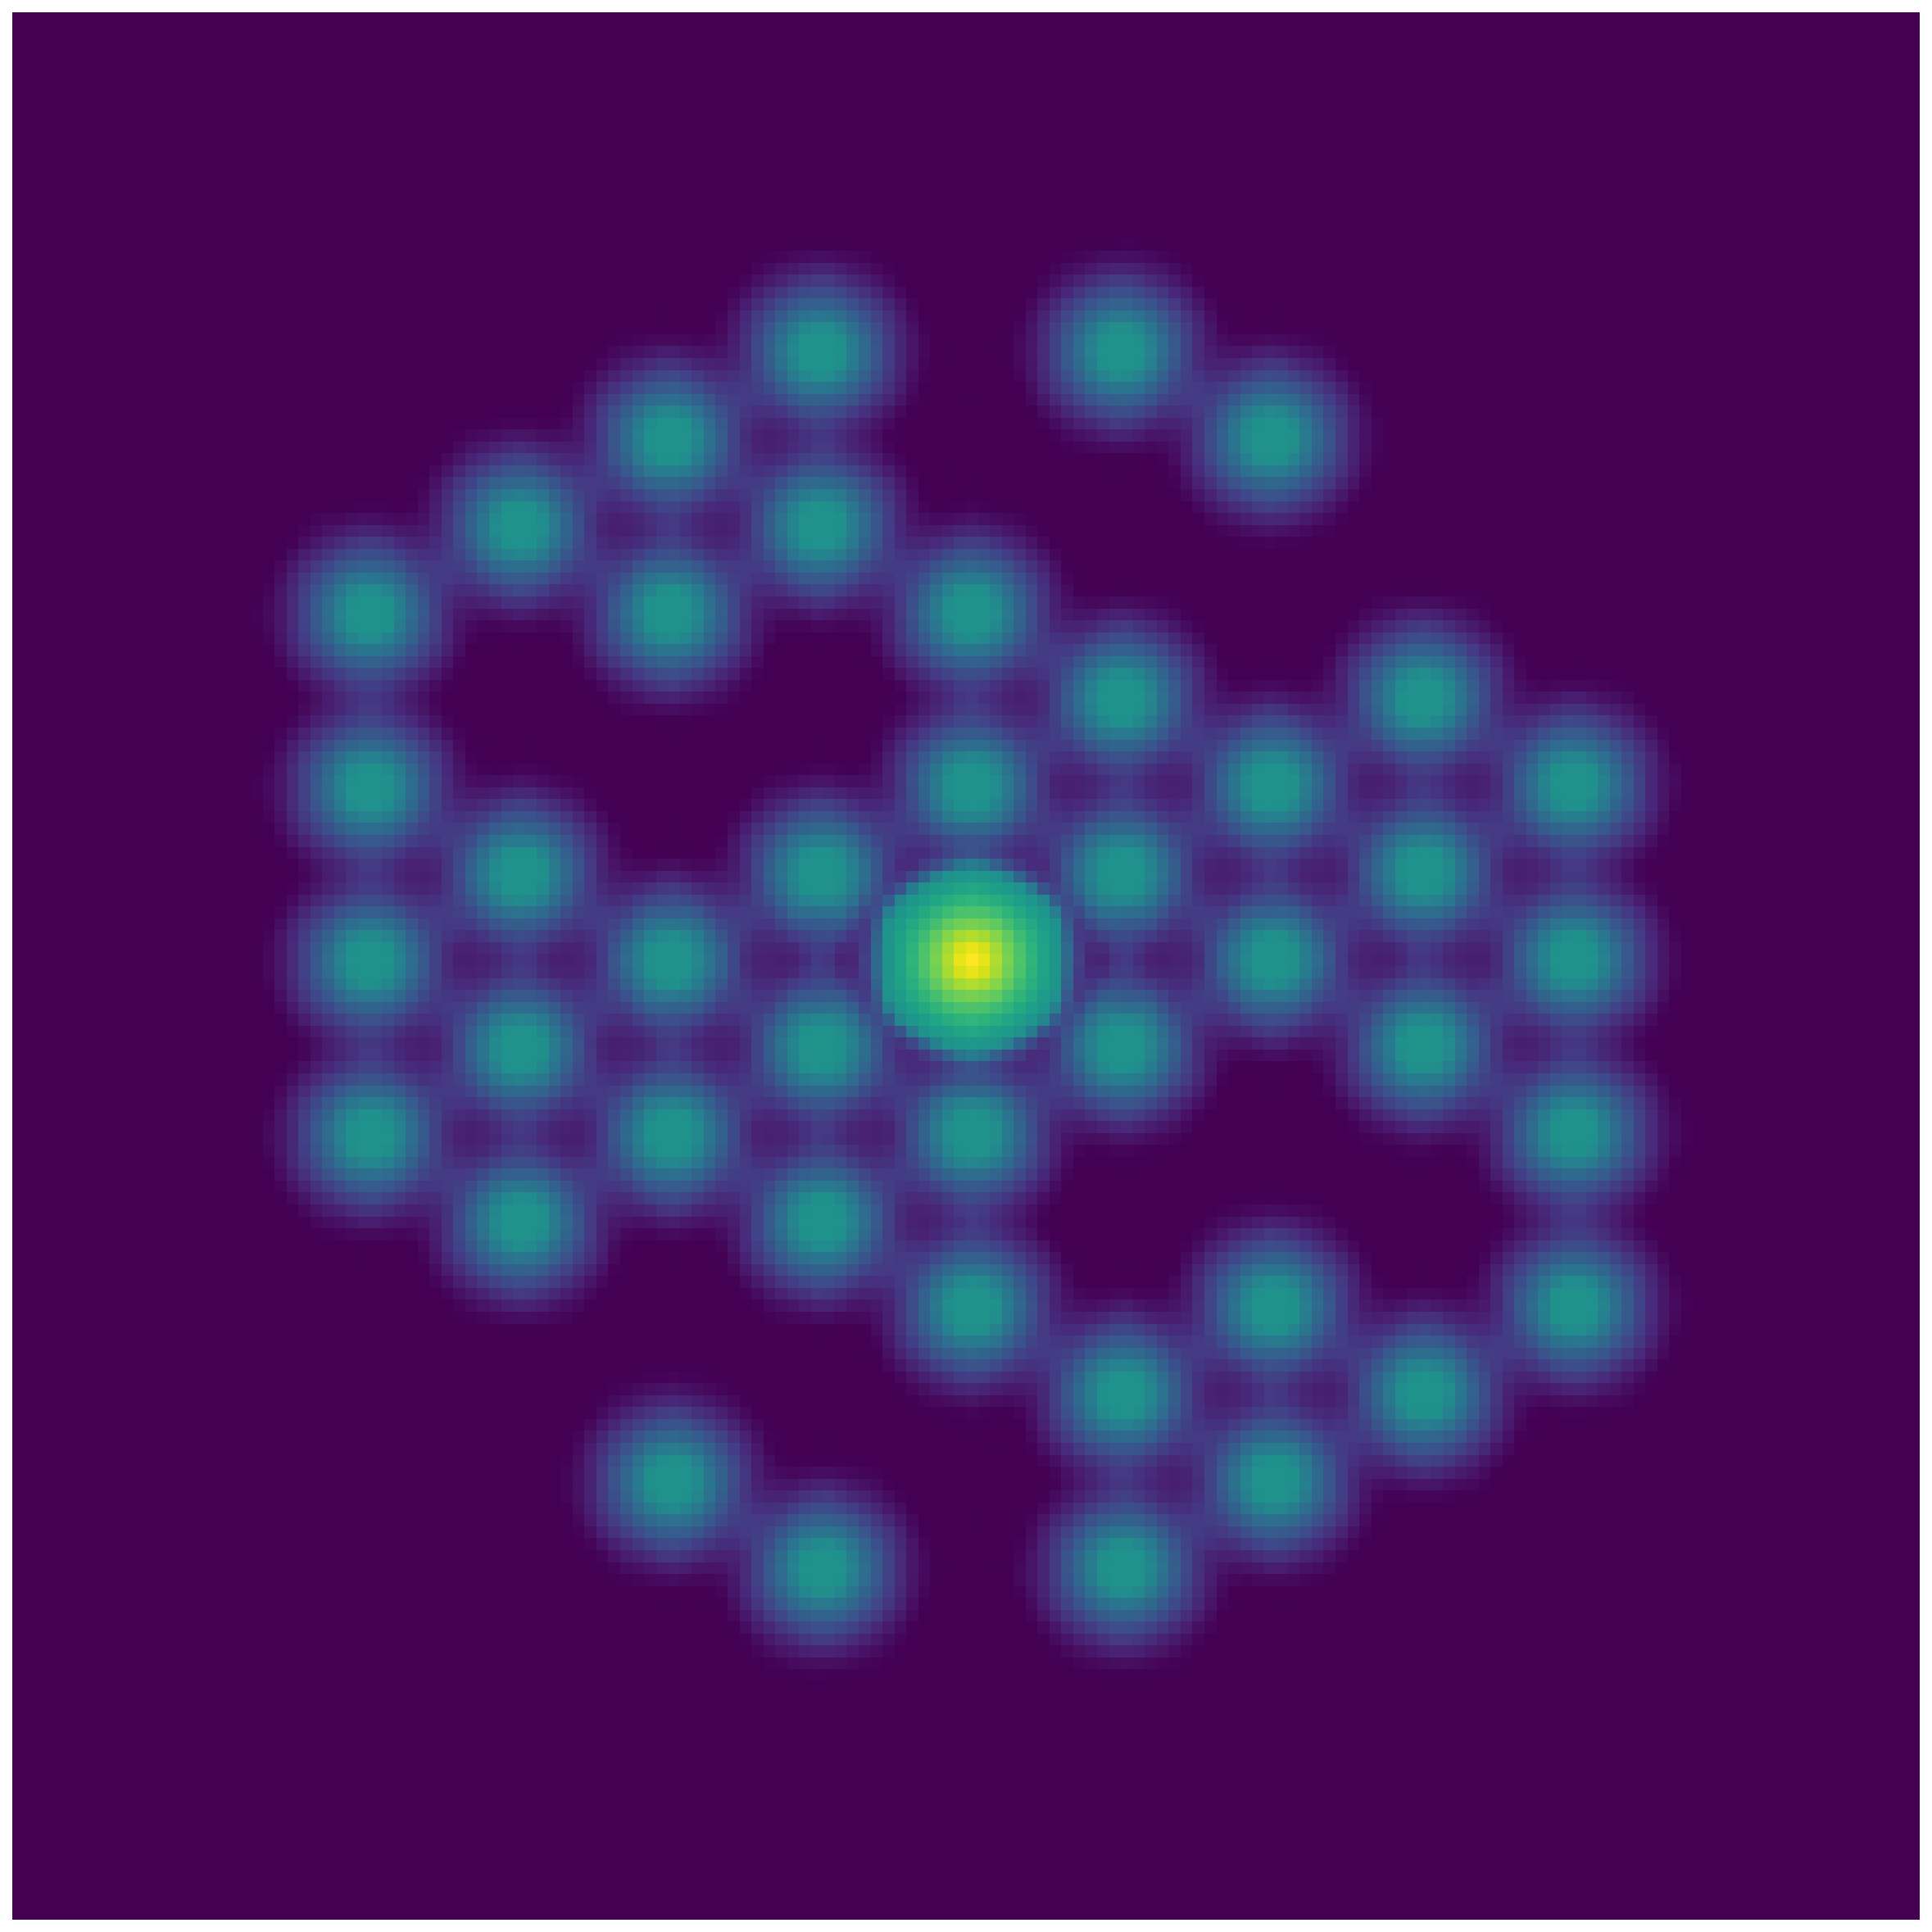

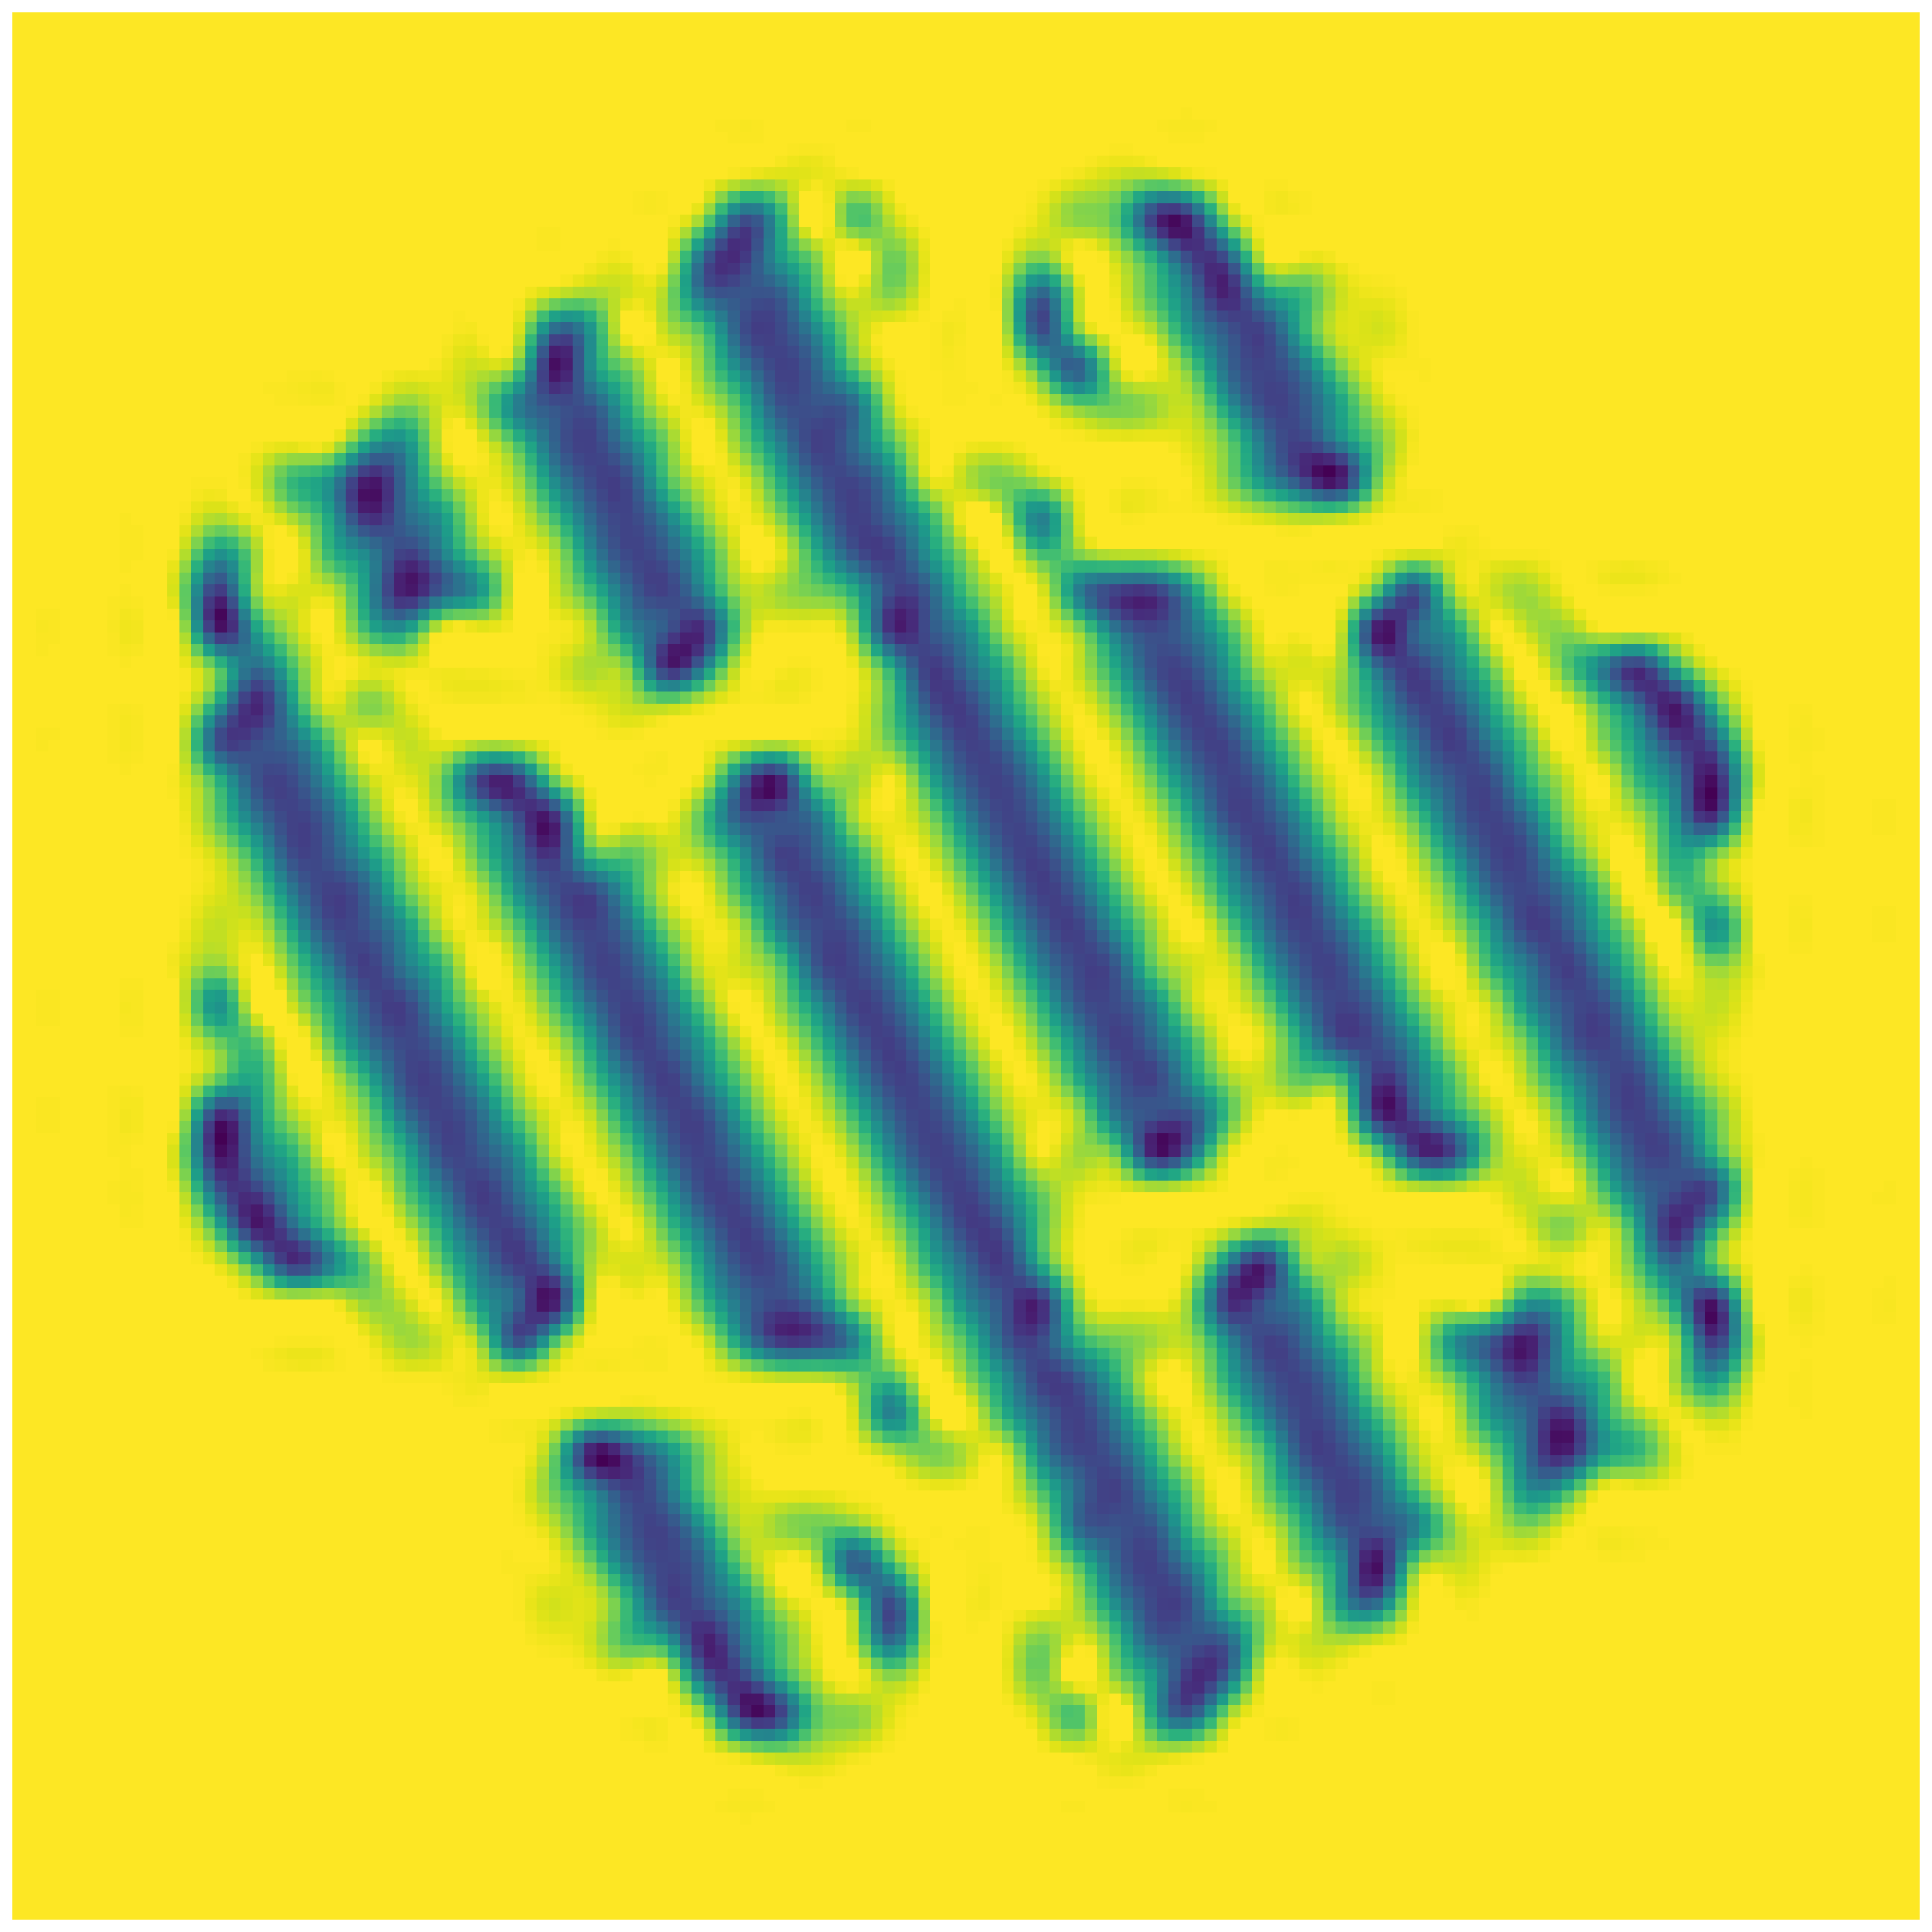

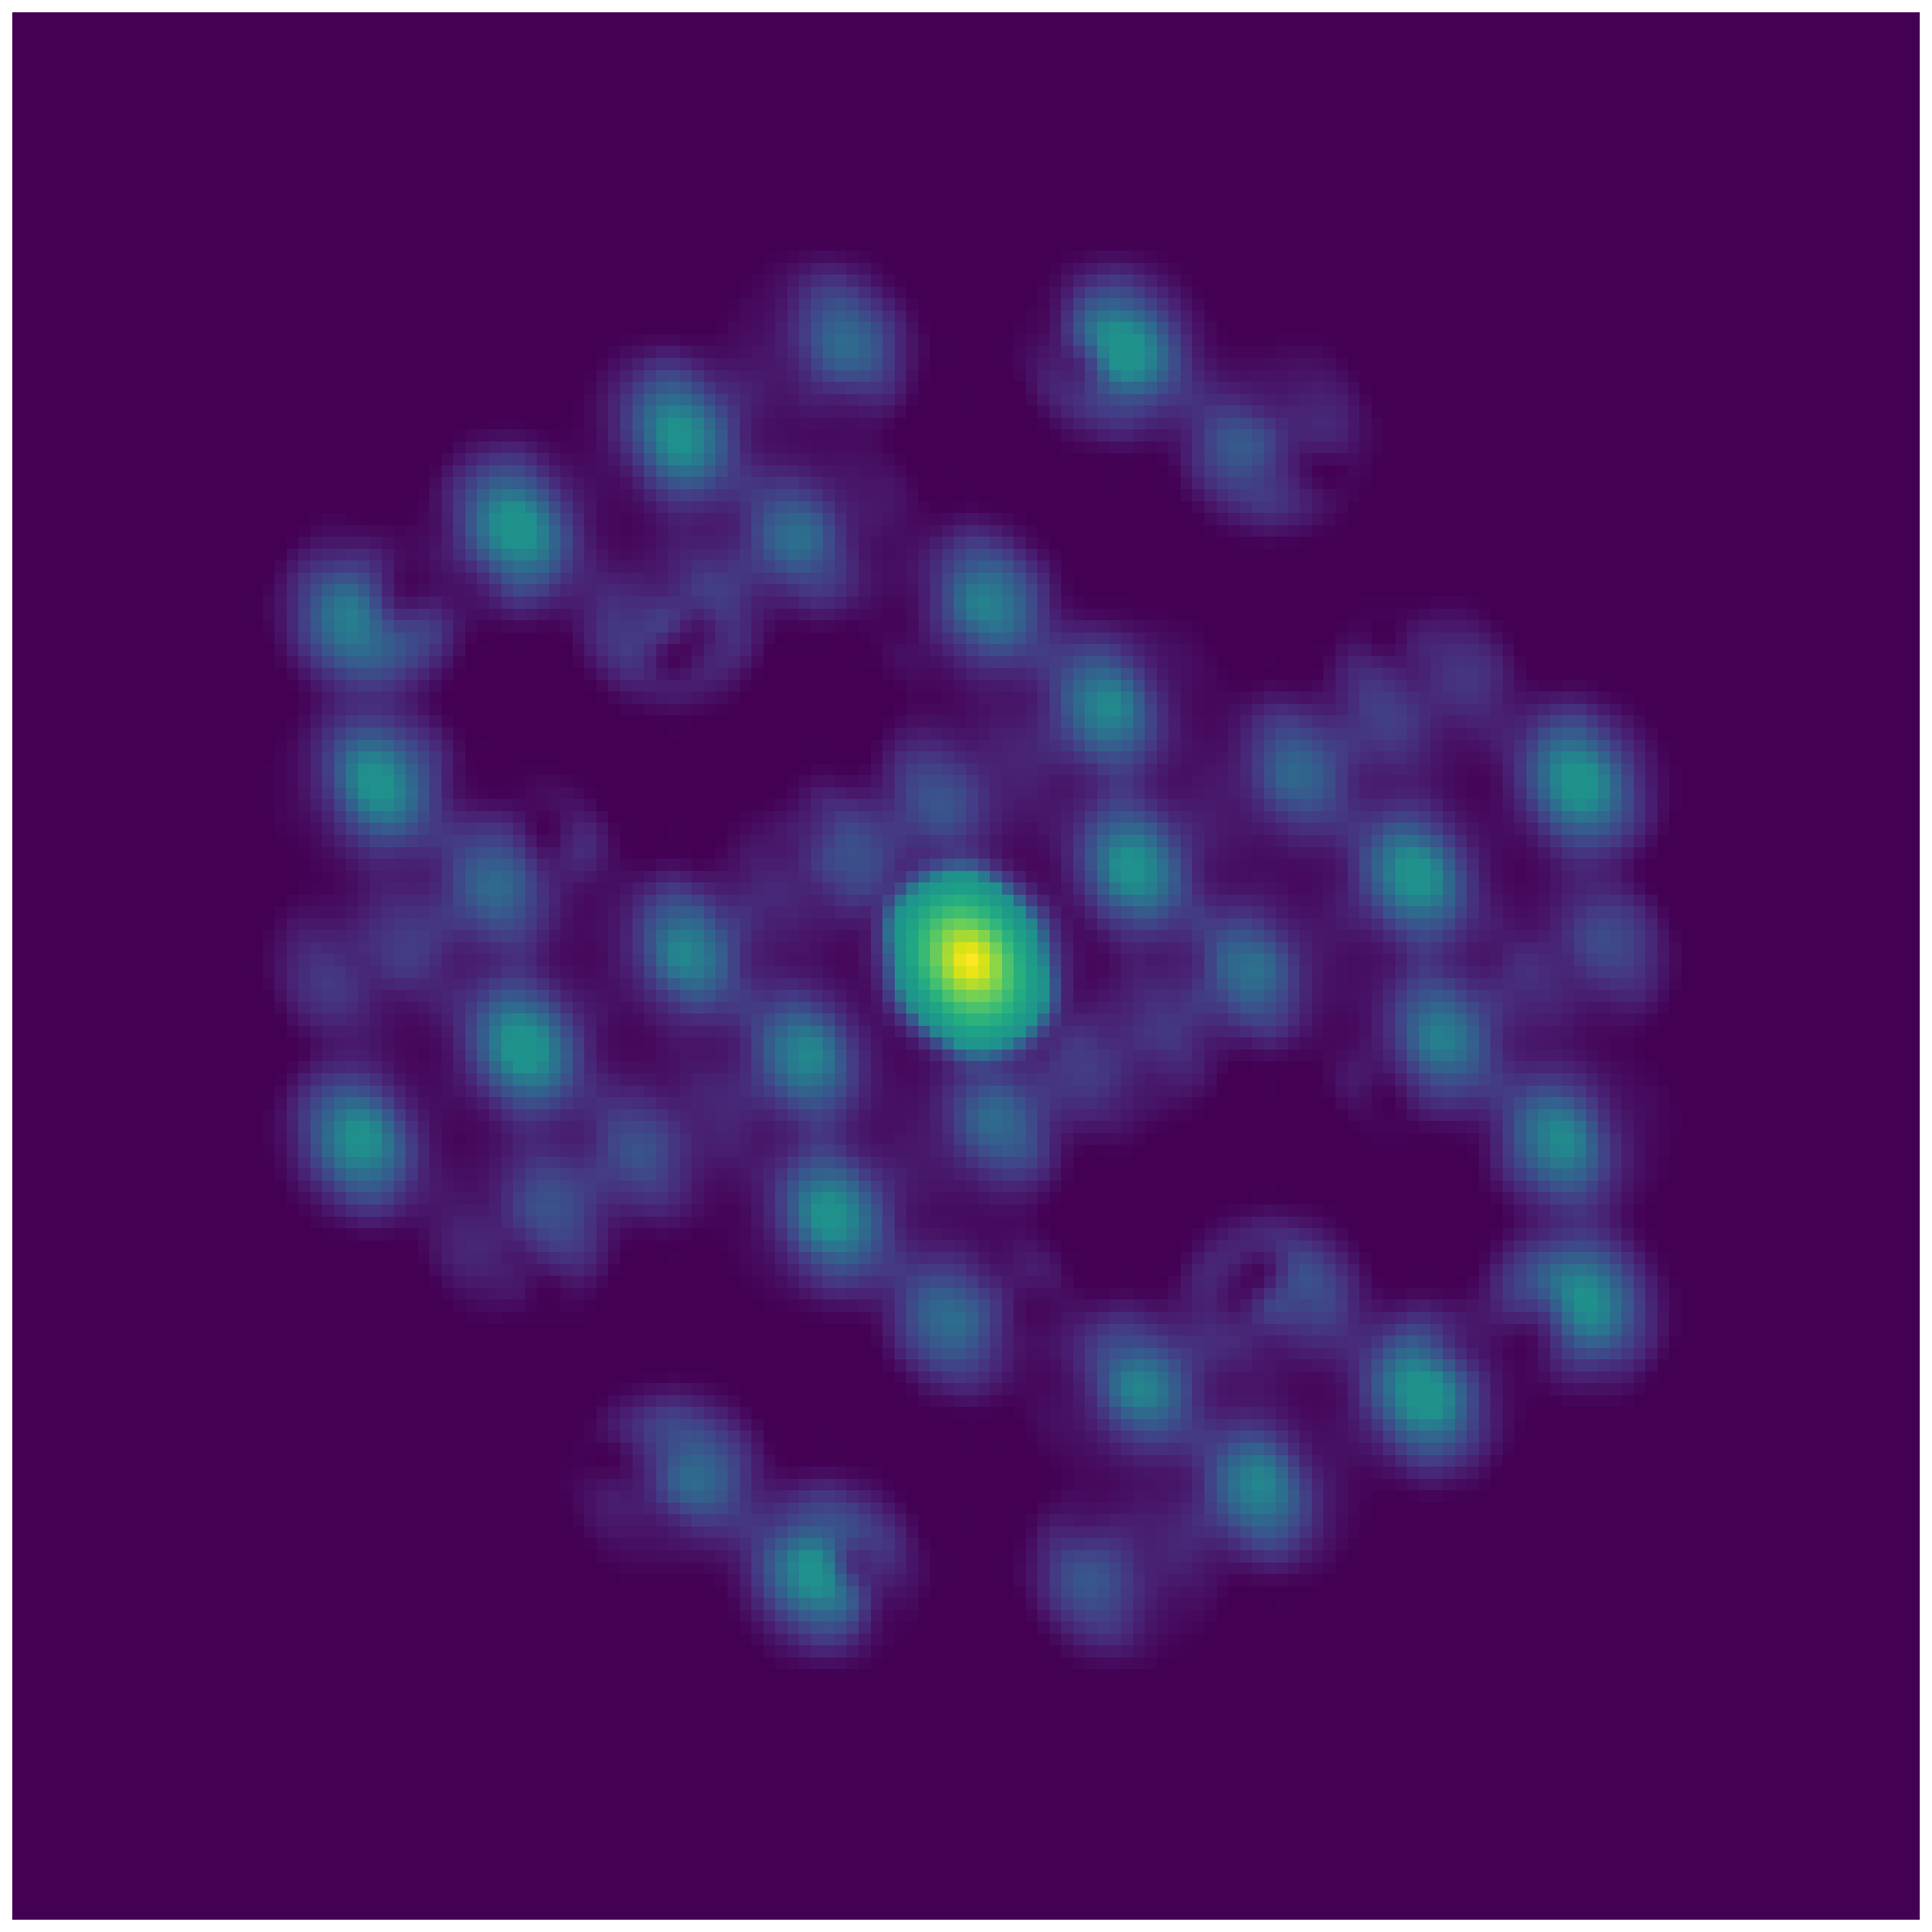

In [380]:
splodge = splodges[0]
log_amp = log_amps[0]
phase = phases[0]


c = splodge.shape[0] // 2
s = 80

splodge = splodge[c - s : c + s, c - s : c + s]
log_amp = log_amp[c - s : c + s, c - s : c + s]
phase = phase[c - s : c + s, c - s : c + s]

vis_map = np.exp(10 * log_amp + 1j * phase)
mid = 5e-4


plt.figure(figsize=(8, 8))
plt.imshow(
    np.abs(splodge),
    cmap="viridis",
    norm=mpl.colors.TwoSlopeNorm(mid),
    # norm=mpl.colors.PowerNorm(0.5),
)
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "splodge.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(wave, cmap="viridis")
# plt.imshow(np.abs(vis_map) ** 0.1, cmap="viridis", norm=mpl.colors.TwoSlopeNorm(1.0))
# plt.contour(
#     np.abs(vis_map),
#     levels=[1.0],
# )
# plt.colorbar()
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "vis_map.png", dpi=300, bbox_inches="tight")
plt.show()

# x = np.abs(splodge * vis_map)
x = np.abs(splodge * wave)
plt.figure(figsize=(8, 8))
plt.imshow(
    x,
    cmap="viridis",
    # norm=mpl.colors.PowerNorm(0.5),
    norm=mpl.colors.TwoSlopeNorm(mid),
)
# plt.contour(
#     x,
#     levels=[mid],
# )
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "vis_out.png", dpi=300, bbox_inches="tight")
plt.show()

In [211]:
import jax.numpy as np

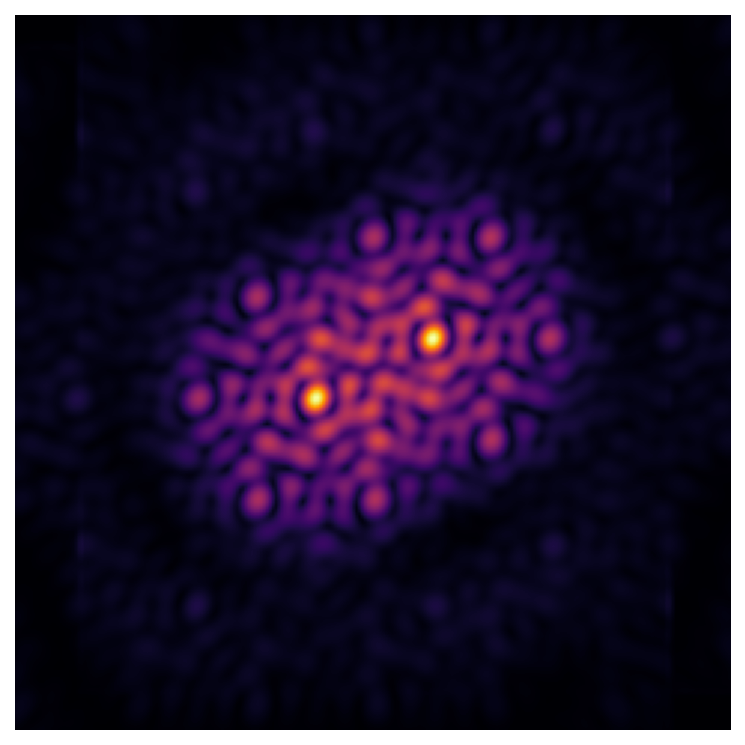

In [222]:
s = 40


two_stars = np.zeros((s, s)).at[s // 4, 0].set(1).at[-s // 4, -1].set(1)

plt.imshow(two_stars, cmap="viridis")

binary = psf.convolve(two_stars)

plt.imshow(binary.data, norm=mpl.colors.PowerNorm(0.5), cmap="inferno")
plt.axis("off")
plt.tight_layout()
plt.savefig(fig_path + "binary.png", dpi=300, bbox_inches="tight")
plt.show()